## SECTION 4-1 로지스틱 회귀

In [3]:
import pandas as pd
from sklearn.inspection._plot import decision_boundary

fish = pd.read_csv('https://raw.githubusercontent.com/rickiepark/hg-mldl/master/fish.csv')
fish.head()

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340


In [4]:
# 데이터 준비

print(pd.unique(fish['Species']))       # 어떤 종류 생선 있는지

# 데이터프레임에서 Species 열을 타깃으로 만들고 나머지 5개 열은 입력 데이터로 사용
fish_input = fish[['Weight', 'Length', 'Diagonal', 'Height', 'Width']]
fish_input.head()

<StringArray>
['Bream', 'Roach', 'Whitefish', 'Parkki', 'Perch', 'Pike', 'Smelt']
Length: 7, dtype: str


,Weight,Length,Diagonal,Height,Width
0,242.0,25.4,30.0,11.5200,4.0200
1,290.0,26.3,31.2,12.4800,4.3056
2,340.0,26.5,31.1,12.3778,4.6961
3,363.0,29.0,33.5,12.7300,4.4555
4,430.0,29.0,34.0,12.4440,5.1340


In [6]:
# 타깃 데이터 준비

fish_target = fish['Species']

# 데이터 훈련 세트 / 테스트 세트 분할
from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = train_test_split(
    fish_input, fish_target, random_state=42
)

In [8]:
# 사이킷런의 StandardScaler 클래스 사용해 훈련 세트 & 테스트 세트 표준화 전처리
    # 훈련 세트의 통계값으로 테스트세트 변환해야함에 주의

from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
ss.fit(train_input)
train_scaled = ss.transform(train_input)
test_scaled = ss.transform(test_input)

In [9]:
# k-최근접 이웃 분류기의 확률 예측

# 최근접 이웃 개수인 k를 3으로 지정하여 사용
from sklearn.neighbors import KNeighborsClassifier
kn = KNeighborsClassifier(n_neighbors=3)
kn.fit(train_scaled, train_target)
print(kn.score(train_scaled, train_target))
print(kn.score(test_scaled, test_target))

0.8907563025210085
0.85


In [11]:
# 사이킷런은 타깃값 자동으로 알파벳순 정렬
# classes_ 속성으로 클래스 순서 확인

print(kn.classes_)

# predict( ) 메서드 사용, 테스트 세트에 있는 처음 5개 샘플의 타깃값을 예측
print(kn.predict(test_scaled[:5]))

['Bream' 'Parkki' 'Perch' 'Pike' 'Roach' 'Smelt' 'Whitefish']
['Perch' 'Smelt' 'Pike' 'Perch' 'Perch']


In [14]:
# 사이킷런의 분류 모델은 predict_proba( ) 메서드로 클래스별 확률값을 반환
# 출력 순서: 앞서 보았던 classes_의 순서

# 테스트 세트의 처음 5개 샘플에 대한 확률 출력
import numpy as np
proba = kn.predict_proba(test_scaled[:5])
print(np.round(proba, decimals=4))

[[0.     0.     1.     0.     0.     0.     0.    ]
 [0.     0.     0.     0.     0.     1.     0.    ]
 [0.     0.     0.     1.     0.     0.     0.    ]
 [0.     0.     0.6667 0.     0.3333 0.     0.    ]
 [0.     0.     0.6667 0.     0.3333 0.     0.    ]]


- 로지스틱 회귀
    - 분류 모델의 일종
    - 선형 회귀와 동일하게 선형 방정식 적용
    - $z = a × (Weight) + b × (Length) + c × (Diagonal) + d × (Height) + e × (Width) + f$
    - z는 어떤 값도 가능하지만 확률이 되려면 0~1(또는 0~100%) 사이 값이 되어야 함
        - 시그모이드 / 로지스틱 함수 사용

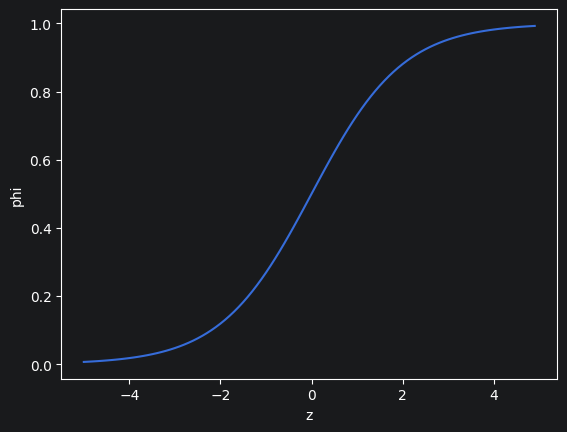

In [15]:
# 넘파이 사용해 시그모이드 그래프 작성

import numpy as np
import matplotlib.pyplot as plt

z = np.arange(-5, 5, 0.1)
phi = 1 / (1 + np.exp(-z))      # 지수함수 계산 위해 exp 사용
plt.plot(z, phi)
plt.xlabel('z')
plt.ylabel('phi')
plt.show()

In [18]:
# 로지스틱 회귀로 이진 분류 수행

# 불리언 인덱싱: 넘파이 배열은 True, False 값 전달해 행 선택
char_arr = np.array(['A', 'B', 'C', 'D', 'E'])
print(char_arr[[True, False, True, False, False]])

['A' 'C']


In [19]:
# 훈련 세트에서 도미(Bream), 빙어(Smelt)만 골라냄
# 도미와 빙어를 or 연산자 사용해 결합
bream_smelt_indexes = (train_target == 'Bream') | (train_target == 'Smelt')
train_bream_smelt = train_scaled[bream_smelt_indexes]
target_bream_smelt = train_target[bream_smelt_indexes]

In [20]:
# 로지스틱 회귀 모델 훈련
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(train_bream_smelt, target_bream_smelt)

# 훈련 모델 사용해 train_bream_smelt에 있는 5개 샘플 예측
print(lr.predict(train_bream_smelt[:5]))

# predict_proba 메서드 통해 예측 확률 출력
print(lr.predict_proba(train_bream_smelt[:5]))

['Bream' 'Smelt' 'Bream' 'Bream' 'Bream']
[[0.99760007 0.00239993]
 [0.02737325 0.97262675]
 [0.99486386 0.00513614]
 [0.98585047 0.01414953]
 [0.99767419 0.00232581]]


In [21]:
# 로지스틱 회귀가 학습한 계수 확인
print(lr.coef_, lr.intercept_)

# decision_function ( ) 메서드로 train_bream_smelt의 처음 5개 샘플의 z값 출력
decisions = lr.decision_function(train_bream_smelt[:5])
print(decisions)

# 파이썬의 사이파이(scipy) 라이브러리 시그모이드 함수 expit ( )으로 decisions 배열의 값을 확률로 변환
from scipy.special import expit
print(expit(decisions))

[[-0.40451732 -0.57582787 -0.66248158 -1.01329614 -0.73123131]] [-2.16172774]
[-6.02991358  3.57043428 -5.26630496 -4.24382314 -6.06135688]
[0.00239993 0.97262675 0.00513614 0.01414953 0.00232581]


- `lr = LogisticRegression(C=20, max_iter=1000)`
    - max_iter=1000
        - 최대 1000번까지 반복해서 충분히 학습
    - C=20
        - 규제(regularization) 의 강도를 조절
        - 로지스틱 회귀는 기본적으로 L2 규제를 사용
            - L2 규제: 릿지 회귀와 같이 계수의 제곱을 규제
        - C의 값 늘려 규제 완화

In [24]:
# 로지스틱 회귀로 다중 분류 수행하기

# LogisticRegression 클래스로 다중 분류 모델 훈련
lr = LogisticRegression(C=20, max_iter=1000)
lr.fit(train_scaled, train_target)
print(lr.score(train_scaled, train_target))
print(lr.score(test_scaled, test_target))

# 테스트 세트의 처음 5개 샘플에 대한 예측을 출력
print(lr.predict(test_scaled[:5]))

# 테스트 세트의 처음 5개 샘플에 대한 예측 확률을 출력(소수점 네 번째 자리에서 반올림)
proba = lr.predict_proba(test_scaled[:5])
print(np.round(proba, decimals=3))

0.9327731092436975
0.925
['Perch' 'Smelt' 'Pike' 'Roach' 'Perch']
[[0.    0.014 0.842 0.    0.135 0.007 0.003]
 [0.    0.003 0.044 0.    0.007 0.946 0.   ]
 [0.    0.    0.034 0.934 0.015 0.016 0.   ]
 [0.011 0.034 0.305 0.006 0.567 0.    0.076]
 [0.    0.    0.904 0.002 0.089 0.002 0.001]]


In [26]:
# 다중 분류에서는 클래스마다 하나씩 선형식이 필요
    # 7개 클래스 분류 위해 7개 선형식 필요

print(lr.coef_.shape, lr.intercept_.shape)
# 5개 특성, 7개 클래스 -> 5열 7행

(7, 5) (7,)


- 이진 분류에서는 시그모이드 함수를 사용해 z를 0과 1 사이의 값으로 변환
- 다중 분류는 이와 달리 소프트맥스(softmax) 함수를 사용하여 7개의 z 값을 확률로 변환

- 소프트맥수 함수
    - $e\_sum = ez1 + ez2 + ez3 + ez4 + ez5 + ez6 + ez7$
    - ez1~ez7을 각각 e_sum으로 나눔
        - $s1 = \dfrac{e^{z1}}{e\_sum}$, $s2 = \dfrac{e^{z2}}{e\_sum}$, ..., $s7 = \dfrac{e^{z7}}{e\_sum}$

In [28]:
# decision_function ( ) 메서드로 z1~z7까지의 값을 구한 다음 소프트맥스 함수를 사용해 확률로 변환

# 테스트 세트 처음 5개에 대한 z1 ~ z7값 계산
decisions = lr.decision_function(test_scaled[:5])
print(np.round(decisions, decimals=2))

[[ -6.51   1.04   5.17  -2.76   3.34   0.35  -0.63]
 [-10.88   1.94   4.78  -2.42   2.99   7.84  -4.25]
 [ -4.34  -6.24   3.17   6.48   2.36   2.43  -3.87]
 [ -0.69   0.45   2.64  -1.21   3.26  -5.7    1.26]
 [ -6.4   -1.99   5.82  -0.13   3.5   -0.09  -0.7 ]]


In [29]:
# 앞서 구한 decision 배열을 softmax( ) 함수에 전달 -> 확률 계산

from scipy.special import softmax
proba = softmax(decisions, axis=1)
print(np.round(proba, decimals=3))

[[0.    0.014 0.842 0.    0.135 0.007 0.003]
 [0.    0.003 0.044 0.    0.007 0.946 0.   ]
 [0.    0.    0.034 0.934 0.015 0.016 0.   ]
 [0.011 0.034 0.305 0.006 0.567 0.    0.076]
 [0.    0.    0.904 0.002 0.089 0.002 0.001]]


## SECTION 4-2. 확률적 경사 하강법

- 점진적 학습
    - 이전에 훈련한 모델 버리고 다시 새로운 모델 훈련하는 방법
        - 기존의 훈련 데이터에 새로운 데이터를 추가하여 모델을 매일매일 다시 훈련
            - 시간이 지날수록 데이터가 늘어나, 모델을 훈련하기 위해 서버를 늘려야 함
        - 새로운 데이터를 추가 시 이전 데이터를 버림 -> 훈련 데이터 크기를 일정하게 유지
            - 데이터를 버릴 때 다른 데이터에 없는 중요한 생선 데이터가 포함되어 있다면 정확한 예측이 불가
    - => 점진적 학습(온라인 학습) 필요
        - 대표적 점진적 학습 알고리즘: 확률적 경사 하강법

- 확률적 경사 하강법
    - 전체 샘플 사용X, 훈련 세트에서 랜덤하게 하나의 샘플 고름
    - 에포크(epoch): 확률적 경사 하강법에서 훈련 세트를 한 번 모두 사용하는 과정
        - 일반적으로 경사 하강법은 수십, 수백번 이상 에포크 사용
    - 미니배치 경사 하강법(minibatch gradient descent): 여러 개의 샘플을 사용해 경사 하강법을 수행하는 방식
    - 배치 경사 하강법(batch gradient descent): 극단적으로 한 번 경사로를 따라 이동하기 위해 전체 샘플을 사용

- 손실 함수
    - 어떤 문제에서 머신러닝 알고리즘이 얼마나 엉터리인지를 측정하는 기준
    - 연속적인 손실 함수: 로지스틱 회귀 모델의 확률. 예측은 0 또는 1이지만 확률은 0~1 사이의 어떤 값도 가능
- 로지스틱 손실 함수(크로스엔트로피 손실 함수)
    - 예측 확률에 로그 함수 적용
    - 로그 사용 이유
        - 손실을 양수로 보기 좋게 만들기
        - 아주 틀린 예측을 크게 벌주기 위해서

In [31]:
# 확률적 경사 하강법 사용한 분류 모델
# SGDClassifier

# fish_csv_data 파일에서 판다스 데이터프레임 생성
import pandas as pd
fish = pd.read_csv('https://raw.githubusercontent.com/rickiepark/hongong-ml/master/fish.csv')

# Species 열을 제외한 나머지 5개는 입력 데이터로 사용
fish_input = fish[['Weight','Length','Diagonal','Height','Width']]
fish_target = fish['Species']

# 사이킷런의 train_test_split 함수 이용 -> 훈련 세트 / 테스트 세트 분할
from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = train_test_split(
    fish_input, fish_target, random_state=42
)

# 훈련 세트 & 테스트 세트 특성 표준화 전처리
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
ss.fit(train_input)
train_scaled = ss.transform(train_input)
test_scaled = ss.transform(test_input)

In [35]:
from sklearn.linear_model import SGDClassifier

# SGDClassifier의 객체를 만들 때 2개의 매개변수를 지정
    # loss=‘log’로 지정하여 로지스틱 손실 함수를 지정
    # max_iter는 수행할 에포크 횟수를 지정. 10으로 지정하여 전체 훈련 세트를 10회 반복
sc = SGDClassifier(loss='log_loss', max_iter=10, random_state=42)
sc.fit(train_scaled, train_target)
print(sc.score(train_scaled, train_target))
print(sc.score(test_scaled, test_target))

0.7815126050420168
0.8


C:\Users\gram15\KnuUniv\4-1\머신러닝\실습\.venv\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


In [36]:
# partial_fit( ) 메서드를 사용하여 SGDClassifier 객체를 다시 만들지 않고 훈련한 모델 sc를 추가로 더 훈련
# 기존 모델을 버리지 않고 계속 업데이트
sc.partial_fit(train_scaled, train_target)
print(sc.score(train_scaled, train_target))
print(sc.score(test_scaled, test_target))

0.8067226890756303
0.825


- 에포크 & 과대/과소 적합
    - if) 에포크 부족: 모델이 훈련 세트 덜 학습 -> 과소적합 모델 가능성 높음
    - if) 에포크 과다: 훈련 세트 완전히 학습 -> 과대적합 모델 가능성 높음
    - 조기 종료: 과대적합 시작 전 훈련 중단

In [37]:
# 훈련 세트 & 테스트 세트 점수 그래프로 나타내기

sc = SGDClassifier(loss='log_loss', random_state=42)
train_score = []
test_score = []
classes = np.unique(train_target)

# 300번 에포크 동안 훈련 반복 진행, 반복마다 훈련 세트 & 테스트 세트 점수 계산하여 기록
for _ in range(0, 300):
    sc.partial_fit(train_scaled, train_target, classes=classes)
    train_score.append(sc.score(train_scaled, train_target))
    test_score.append(sc.score(test_scaled, test_target))

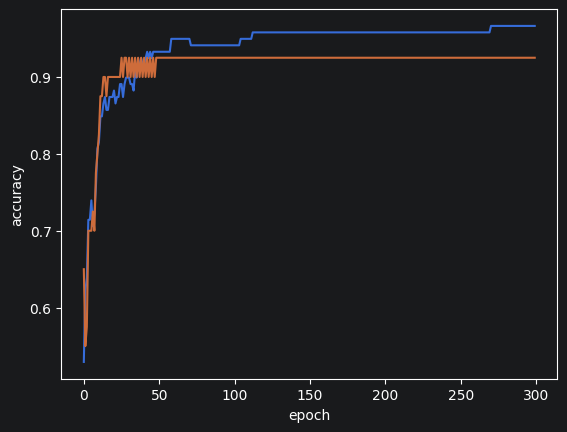

In [38]:
# 훈련 세트 & 테스트 세트 점수 그래프 출력
plt.plot(train_score)
plt.plot(test_score)
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.show()

In [39]:
# SGDClassifier의 반복 횟수 100에 맞추고 모델 재훈련
sc = SGDClassifier(loss='log_loss', max_iter=100, tol=None, random_state=42)
sc.fit(train_scaled, train_target)
print(sc.score(train_scaled, train_target))
print(sc.score(test_scaled, test_target))

0.957983193277311
0.925


In [40]:
# SGDClassifier loss 매개변수 기본값 hinge

sc = SGDClassifier(loss='hinge', max_iter=100, tol=None, random_state=42)
sc.fit(train_scaled, train_target)
print(sc.score(train_scaled, train_target))
print(sc.score(test_scaled, test_target))

0.9495798319327731
0.925
